# Chương 4 — Vanilla RNN: NumPy scratch, Keras và PyTorch

Notebook đọc lại artifact Phase 5, không huấn luyện lại và không dùng TEST để chọn cấu hình. Mục tiêu là kiểm tra provenance, tái tính metric, xác nhận ba framework dùng cùng sample, và trình bày failure result AAPL so với naive last-Close.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, mean_absolute_error,
                             mean_squared_error, r2_score)

start = Path.cwd().resolve()
ROOT = next(path for path in (start, *start.parents) if (path / "term_paper").exists())
TERM = ROOT / "term_paper"
METRICS = TERM / "artifacts" / "metrics"
FIGURES = TERM / "artifacts" / "figures" / "ch4"
MANIFESTS = TERM / "artifacts" / "manifests" / "ch4"
print("Workspace:", ROOT)

Workspace: C:\DATA\assign


## 1. Protocol khóa trước thực nghiệm

- Vanilla RNN `tanh`, many-to-one, hidden size 32, 1 recurrent layer và 1 head.
- Customer: sequence 8×5, subset cố định 30.000/8.000/8.000 từ split A06; BCE có class weight.
- AAPL: sequence 30×5, toàn bộ 1.915/411/410; MSE trên training scale, metric inverse về USD.
- Adam, gradient clipping 1,0; learning rate 0,003 hoặc 0,001; chọn bằng VALIDATION.
- Seed 42, 52, 62. Threshold customer được chọn riêng trên VALIDATION; TEST chỉ đánh giá sau khi khóa.

In [2]:
display(pd.read_csv(METRICS / "ch4_dataset_summary.csv"))
for dataset in ("ch4_online_retail_customer_week", "ch4_aapl_next_close"):
    metadata = json.loads((MANIFESTS / f"{dataset}_metadata.json").read_text(encoding="utf-8"))
    print(dataset, metadata["split_sizes"], metadata["date_ranges"], metadata["split_sha256"])

,dataset_id,source_samples,sequence,task,matched_train,matched_val,matched_test
0,ch4_online_retail_customer_week,350864,8×5 customer-week,binary classification,30000,8000,8000
1,ch4_aapl_next_close,2736,30×5 trading-day,next-Close regression,1915,411,410


ch4_online_retail_customer_week {'train': 30000, 'val': 8000, 'test': 8000} {'train': ['2010-02-01', '2011-07-11'], 'val': ['2011-07-18', '2011-09-19'], 'test': ['2011-09-26', '2011-11-28']} 6b9854be5d7066df378c0a202255f86932b5ab2d1a2753ef431fbc4a84d16a5c
ch4_aapl_next_close {'train': 1915, 'val': 411, 'test': 410} {'train': ['2015-02-17', '2022-09-22'], 'val': ['2022-09-23', '2024-05-13'], 'test': ['2024-05-14', '2025-12-31']} 32245f8c39a4dcd36ff7336641a462bdd5e5eaeff76cf0fbb791705ab8e614bf


## 2. Phân bố và trục thời gian

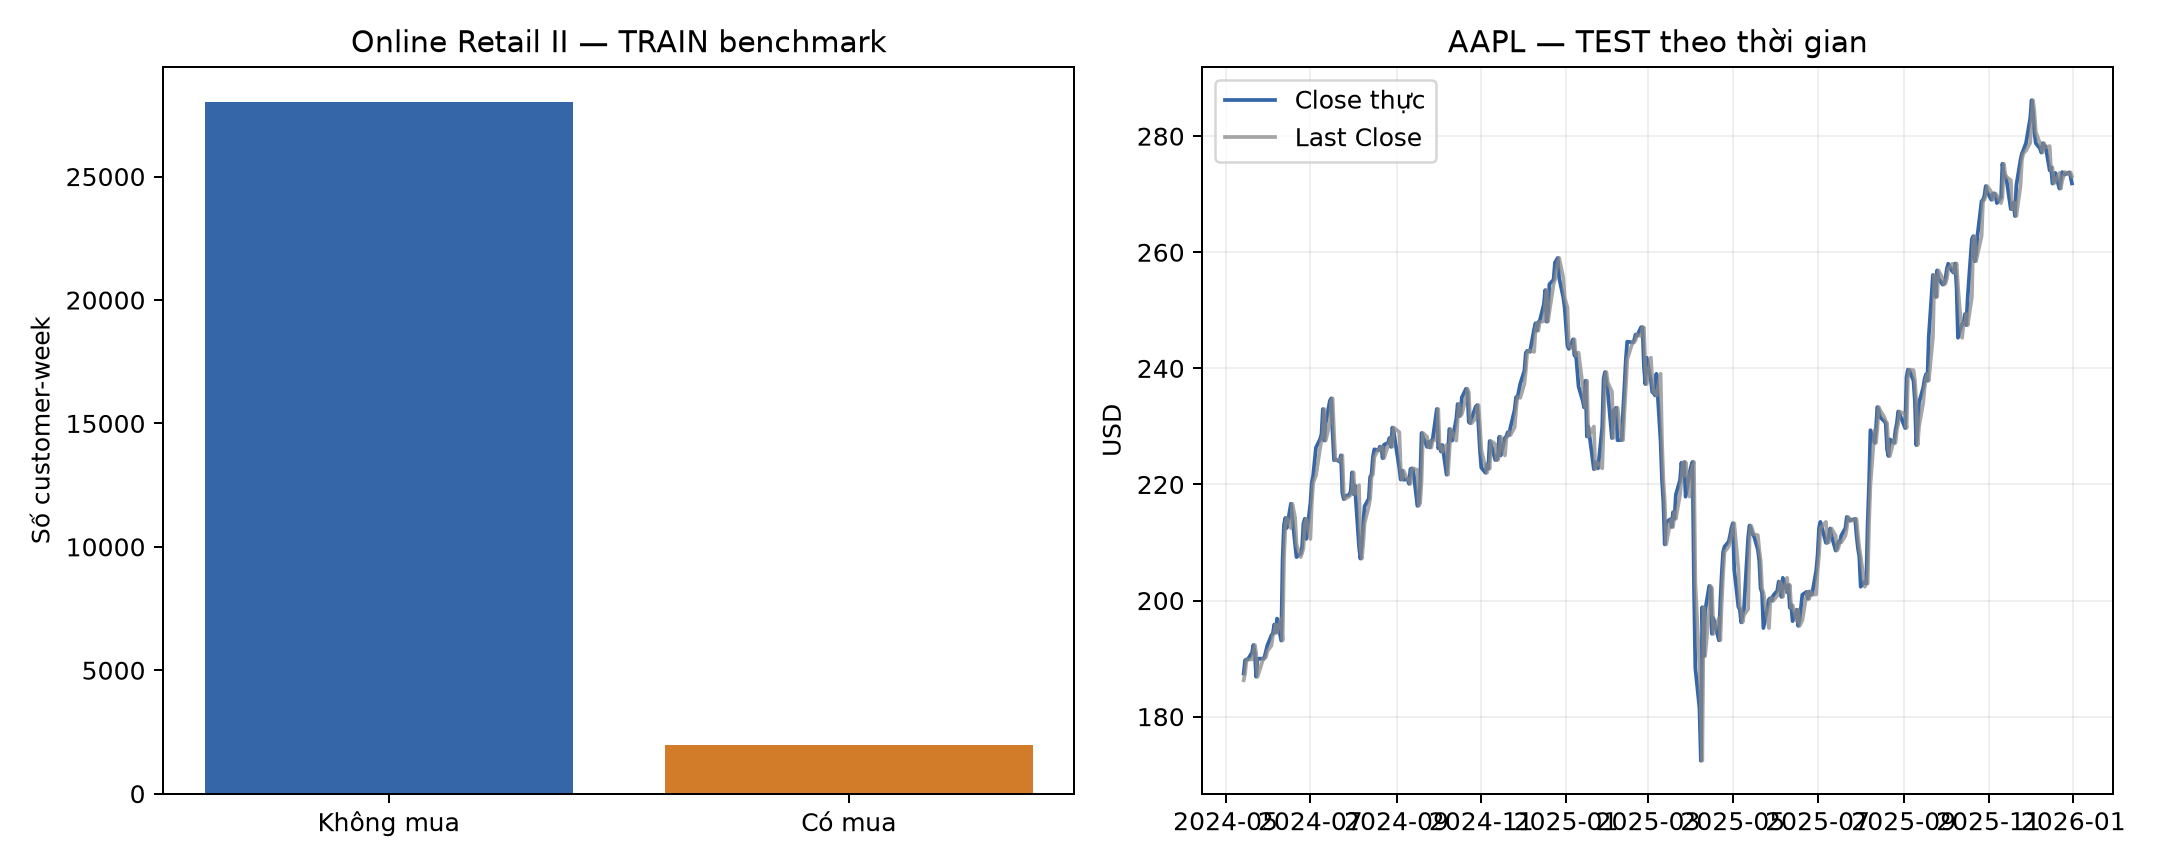

In [3]:
display(Image(filename=str(FIGURES / "ch4_dataset_overview.png")))

Customer-week mất cân bằng mạnh nên accuracy không đủ. AAPL có mức giá TEST cao hơn phần lớn TRAIN, tạo distribution shift rõ và khiến baseline bám giá gần nhất trở thành đối chứng bắt buộc.

## 3. Tái tính metric từ prediction artifact

In [4]:
comparison = pd.read_csv(METRICS / "ch4_framework_comparison.csv")
checks = []
for _, row in comparison.iterrows():
    frame = pd.read_csv(TERM / row["prediction_path"])
    if row.task == "binary":
        pred = (frame.score_or_prediction >= frame.threshold.iloc[0]).astype(int)
        values = {"f1": f1_score(frame.y_true, pred),
                  "roc_auc": roc_auc_score(frame.y_true, frame.score_or_prediction),
                  "pr_auc": average_precision_score(frame.y_true, frame.score_or_prediction)}
    else:
        values = {"mae": mean_absolute_error(frame.y_true, frame.score_or_prediction),
                  "rmse": mean_squared_error(frame.y_true, frame.score_or_prediction) ** 0.5,
                  "r2": r2_score(frame.y_true, frame.score_or_prediction)}
    delta = max(abs(values[name] - row[name]) for name in values)
    checks.append({"dataset": row.dataset_id, "framework": row.framework,
                   "seed": row.seed, "max_metric_delta": delta, "samples": len(frame)})
checks = pd.DataFrame(checks); display(checks)
assert checks.max_metric_delta.max() < 1e-12
print("PASS: metric của 18 run tái tính khớp prediction CSV.")

,dataset,framework,seed,max_metric_delta,samples
0,ch4_aapl_next_close,keras,42,0.000000e+00,410
1,ch4_aapl_next_close,keras,52,0.000000e+00,410
2,ch4_aapl_next_close,keras,62,5.551115e-17,410
3,ch4_aapl_next_close,numpy,42,0.000000e+00,410
4,ch4_aapl_next_close,numpy,52,0.000000e+00,410
5,ch4_aapl_next_close,numpy,62,2.220446e-16,410
6,ch4_aapl_next_close,pytorch,42,3.552714e-15,410
7,ch4_aapl_next_close,pytorch,52,3.552714e-15,410
8,ch4_aapl_next_close,pytorch,62,3.552714e-15,410
9,ch4_online_retail_customer_week,keras,42,0.000000e+00,8000


PASS: metric của 18 run tái tính khớp prediction CSV.


## 4. Sample-key parity

In [5]:
for dataset in comparison.dataset_id.unique():
    for seed in sorted(comparison.seed.unique()):
        selected = comparison[(comparison.dataset_id == dataset) & (comparison.seed == seed)]
        frames = [pd.read_csv(TERM / row.prediction_path)[["sample_key", "y_true"]].astype(str)
                  for _, row in selected.iterrows()]
        assert len(frames) == 3 and frames[0].reset_index(drop=True).equals(frames[1].reset_index(drop=True))
        assert frames[0].reset_index(drop=True).equals(frames[2].reset_index(drop=True))
print("PASS: NumPy, Keras và PyTorch dùng cùng TEST keys/dates/targets.")

PASS: NumPy, Keras và PyTorch dùng cùng TEST keys/dates/targets.


## 5. Customer next-week purchase

,dataset_id,framework,run_count,parameter_count,primary_metric_mean,primary_metric_std,secondary_metric_mean,secondary_metric_std,training_seconds_mean,training_seconds_std,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
3,ch4_online_retail_customer_week,keras,3,1249,0.298543,0.006955,0.221733,0.013881,6.256337,3.633985,...,0.274894,0.049177,0.340489,0.055495,0.298543,0.006955,0.709370,0.000499,0.221733,0.013881
4,ch4_online_retail_customer_week,numpy,3,1249,0.286422,0.027331,0.216303,0.025059,3.974121,2.685553,...,0.255832,0.076093,0.353608,0.060858,0.286422,0.027331,0.708092,0.005753,0.216303,0.025059
5,ch4_online_retail_customer_week,pytorch,3,1249,0.326461,0.005849,0.246594,0.001310,7.427362,6.556973,...,0.302604,0.025145,0.357185,0.024288,0.326461,0.005849,0.713321,0.001144,0.246594,0.001310


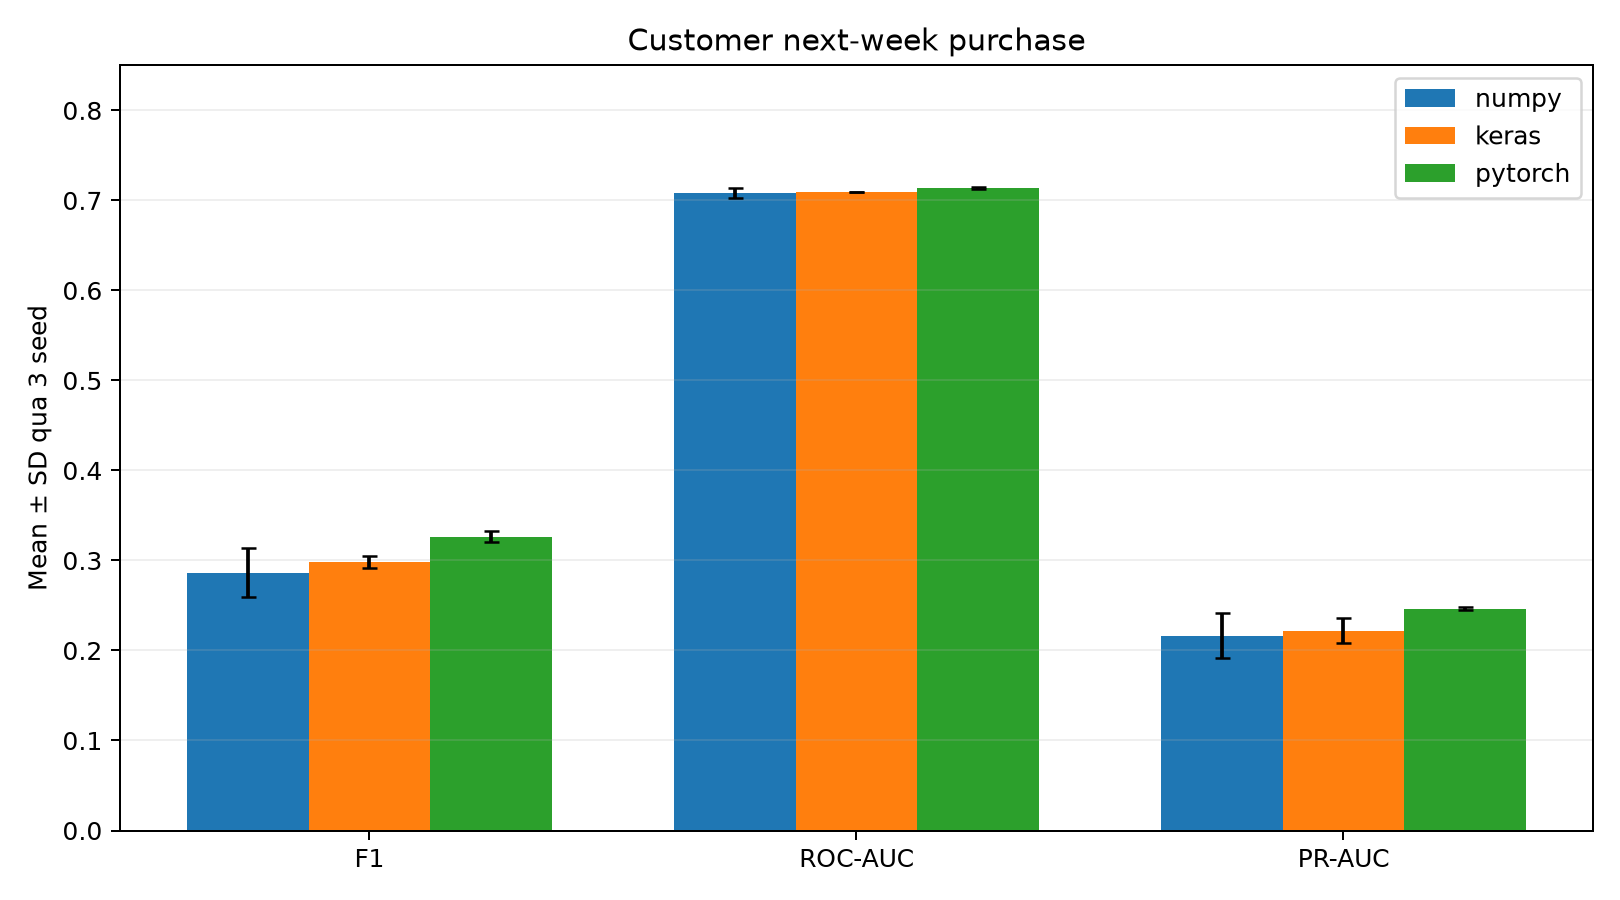

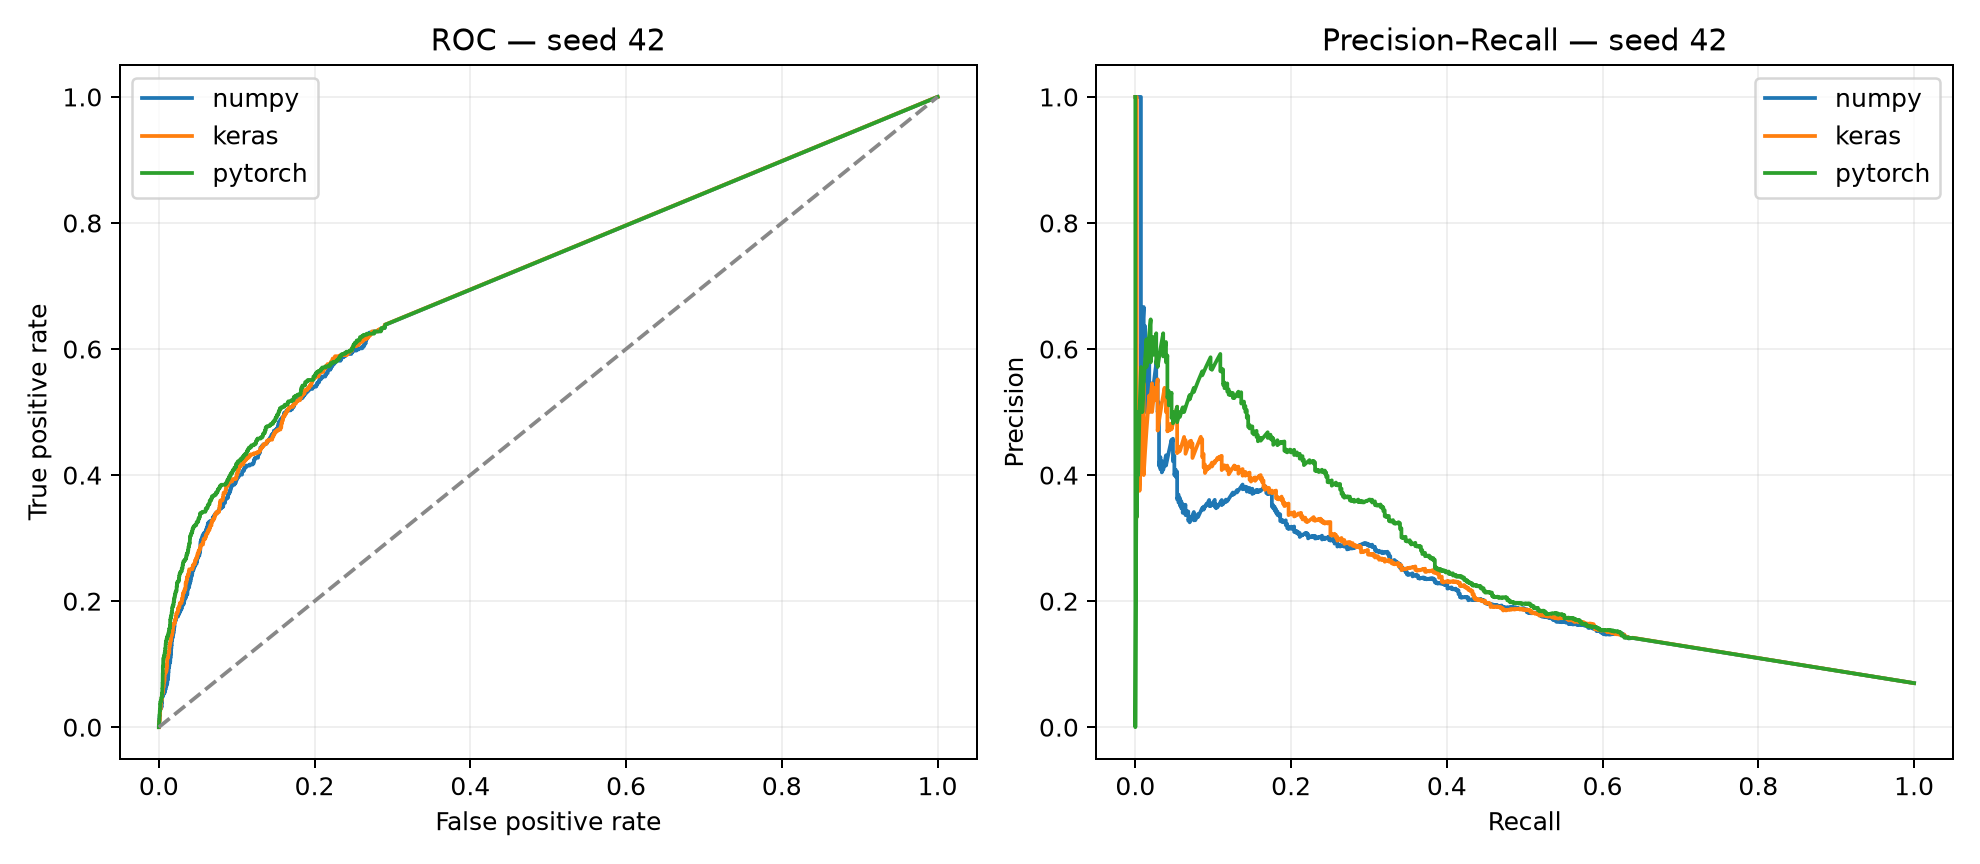

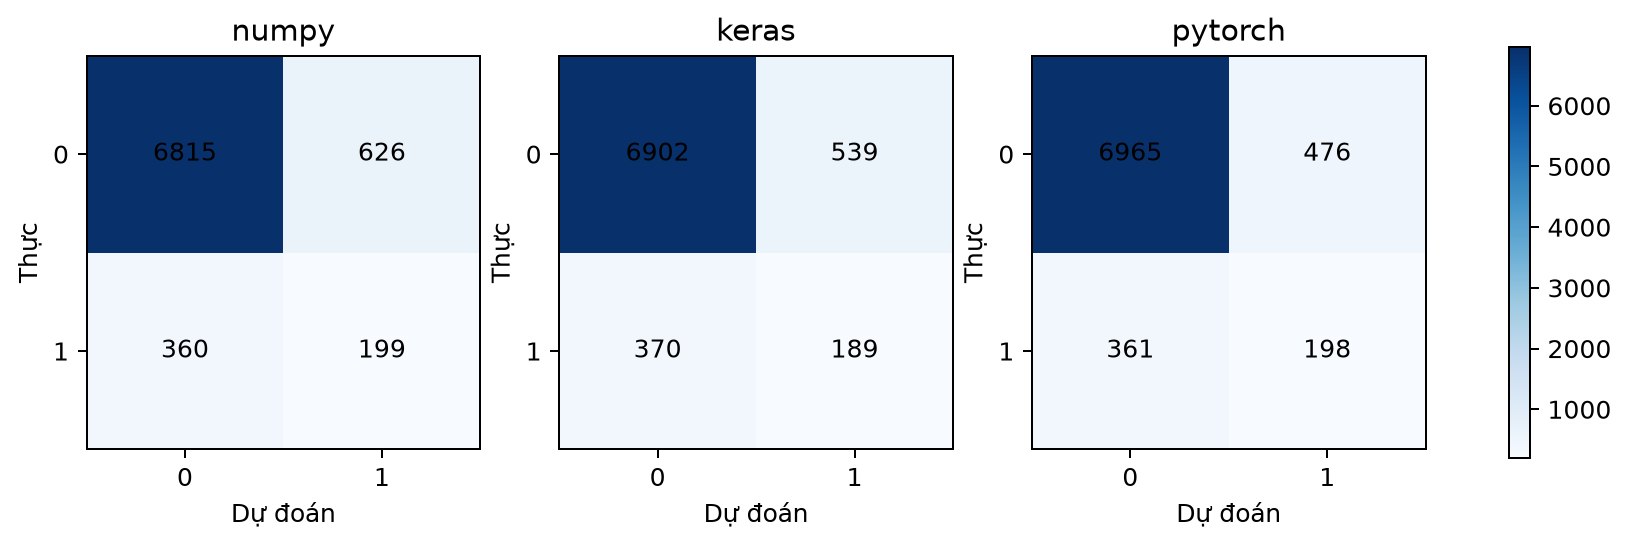

In [6]:
summary = pd.read_csv(METRICS / "ch4_framework_summary.csv")
display(summary[summary.dataset_id == "ch4_online_retail_customer_week"])
display(Image(filename=str(FIGURES / "ch4_customer_metrics.png")))
display(Image(filename=str(FIGURES / "ch4_customer_roc_pr.png")))
display(Image(filename=str(FIGURES / "ch4_customer_confusion_matrices.png")))

F1 và PR-AUC cho thấy khác biệt giữa ba implementation trong cùng protocol, còn confusion matrix làm rõ cái giá của recall: nhiều false positive hơn. Threshold đều được chọn trên VALIDATION, không tối ưu từ TEST.

## 6. AAPL next-Close và baseline

,dataset_id,framework,run_count,parameter_count,primary_metric_mean,primary_metric_std,secondary_metric_mean,secondary_metric_std,training_seconds_mean,training_seconds_std,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,ch4_aapl_next_close,keras,3,1249,32.753321,6.050942,28.116018,5.332888,15.810839,3.424912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ch4_aapl_next_close,numpy,3,1249,36.974134,4.922072,32.002797,4.703907,7.103021,7.101486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ch4_aapl_next_close,pytorch,3,1249,27.790378,2.612940,23.983710,2.508594,14.249503,17.276775,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,framework,seed,mae,rmse,r2,naive_mae,naive_rmse,naive_r2
0,keras,42,30.660702,35.307118,-1.302556,2.617707,3.878928,0.972209
1,keras,52,31.699922,37.108694,-1.543530,2.617707,3.878928,0.972209
2,keras,62,21.987430,25.844151,-0.233702,2.617707,3.878928,0.972209
3,numpy,42,28.321947,33.077331,-1.020908,2.617707,3.878928,0.972209
4,numpy,52,37.302304,42.505550,-2.337159,2.617707,3.878928,0.972209
5,numpy,62,30.384138,35.339522,-1.306784,2.617707,3.878928,0.972209
6,pytorch,42,26.880334,30.807477,-0.753064,2.617707,3.878928,0.972209
7,pytorch,52,22.520621,26.264754,-0.274184,2.617707,3.878928,0.972209
8,pytorch,62,22.550175,26.298904,-0.277500,2.617707,3.878928,0.972209


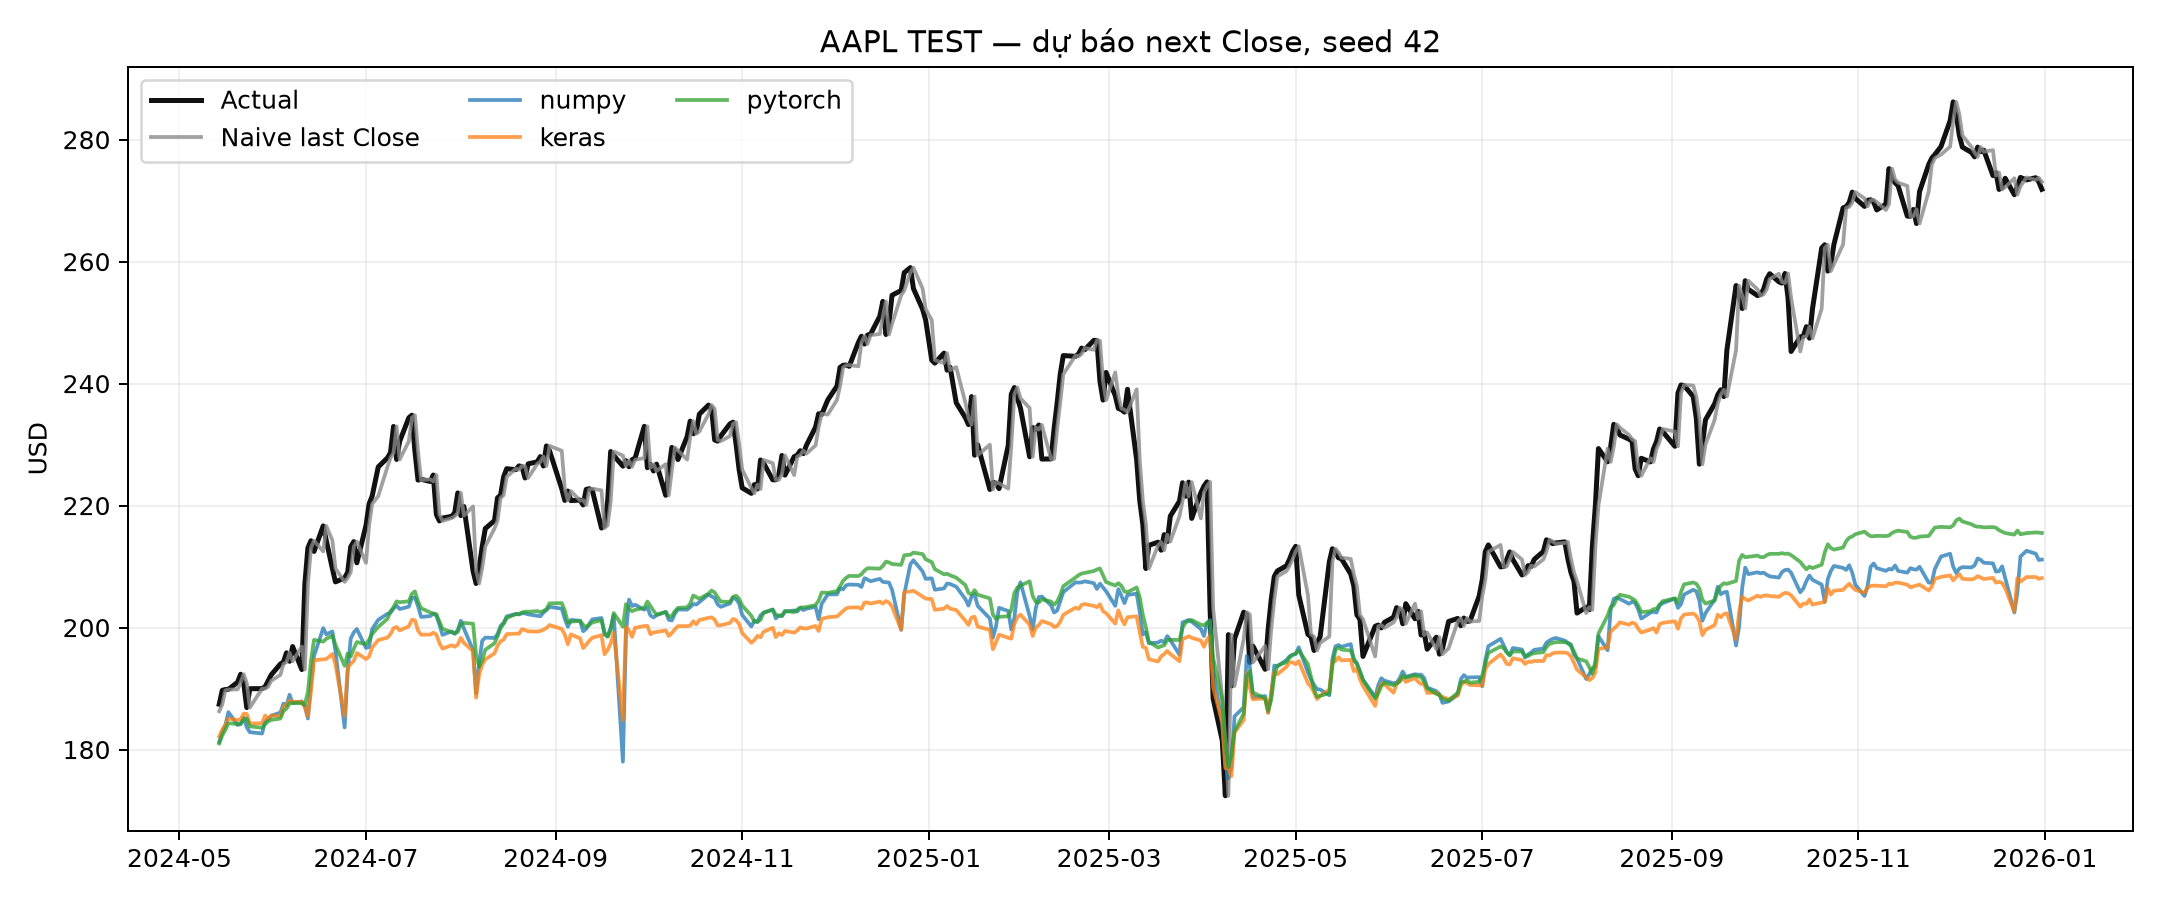

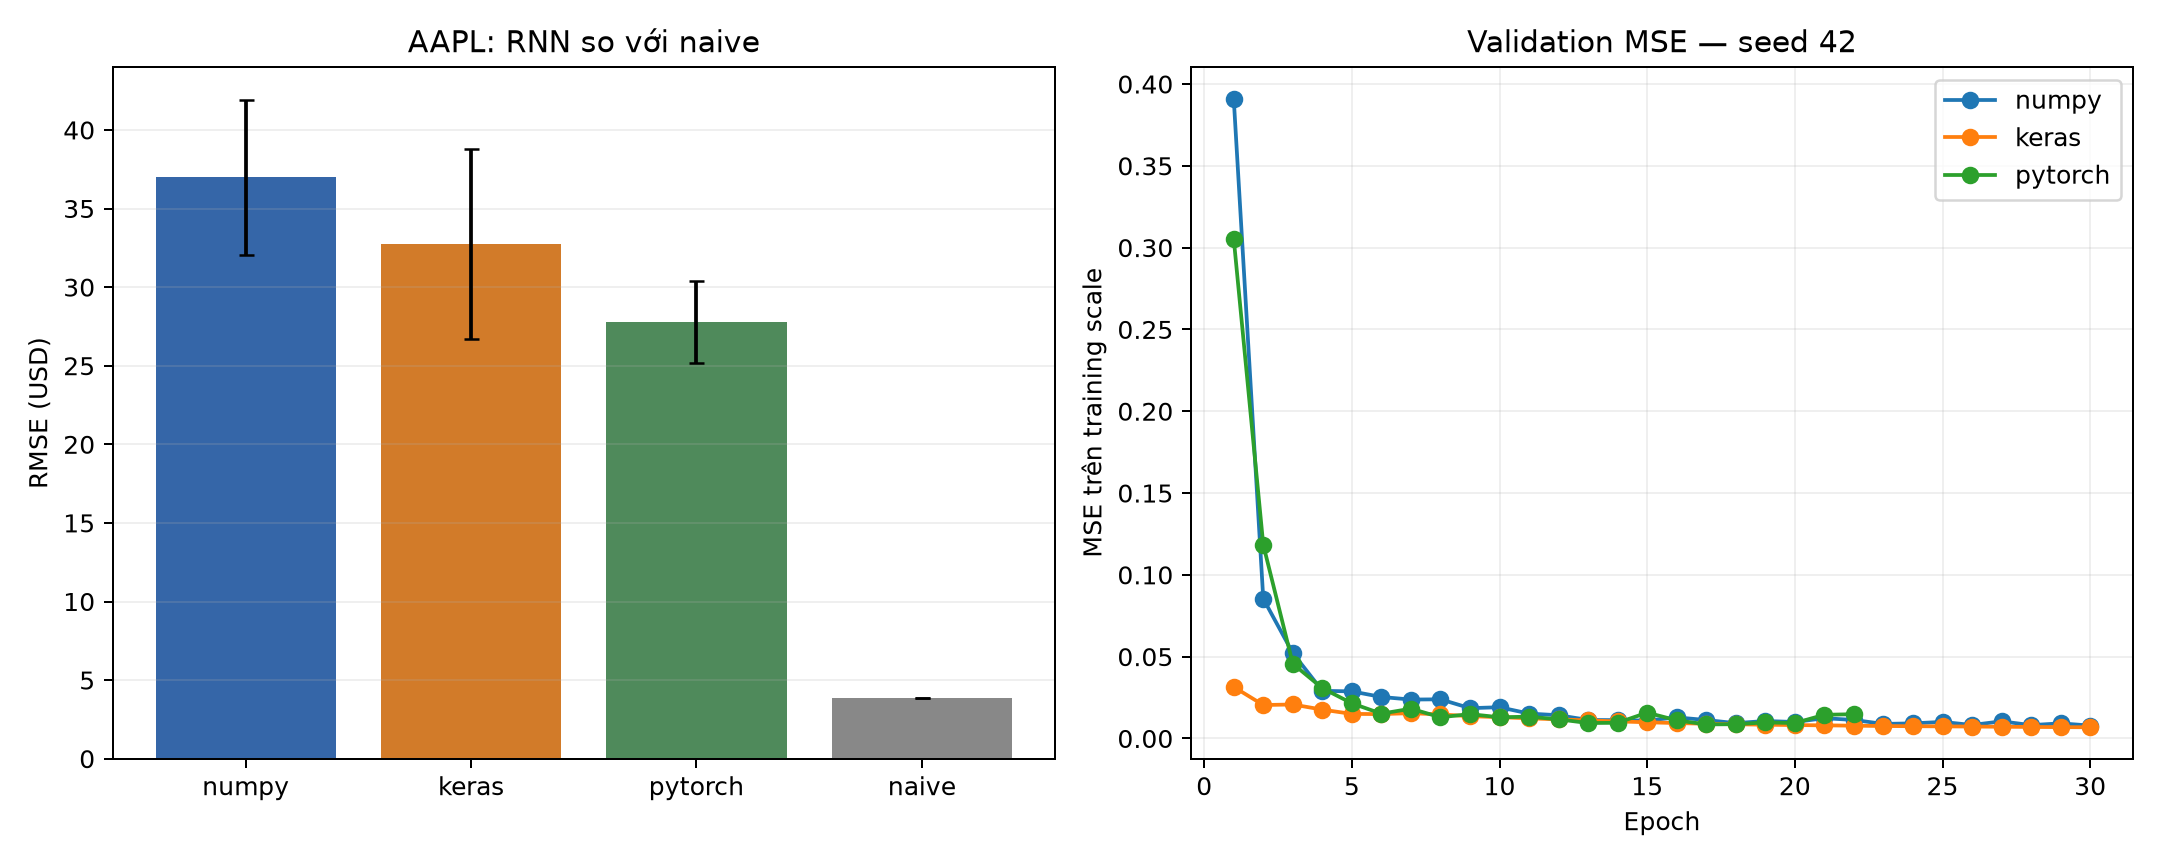

PASS: naive last-Close thắng mọi RNN run trong protocol này.


In [7]:
display(summary[summary.dataset_id == "ch4_aapl_next_close"])
stock = comparison[comparison.dataset_id == "ch4_aapl_next_close"]
display(stock[["framework", "seed", "mae", "rmse", "r2", "naive_mae", "naive_rmse", "naive_r2"]])
display(Image(filename=str(FIGURES / "ch4_stock_actual_vs_predicted.png")))
display(Image(filename=str(FIGURES / "ch4_stock_rmse_and_validation.png")))
assert (stock.rmse > stock.naive_rmse).all()
print("PASS: naive last-Close thắng mọi RNN run trong protocol này.")

## 7. Đối chiếu A06 và kết luận kiểm chứng

Track matched hidden-32 không thay thế kết quả A06 hidden-64; bảng dưới giữ A06 như bằng chứng full-data/reference riêng. Không kết quả nào cho phép khuyến nghị đầu tư.

In [8]:
display(pd.read_csv(METRICS / "ch4_a06_reference.csv"))

,dataset_id,model,hidden_size,accuracy,precision,recall,f1,roc_auc,parameter_count,training_seconds,mae,rmse,r2,source_sha256
0,customer_full_a06,PyTorch RNN,64.0,0.758162,0.158698,0.572161,0.248477,0.700935,4609.0,151.063638,NaN,NaN,NaN,75d238b00af85b46e5b9f13d3519671cd5658407396a80...
1,customer_full_a06,Keras SimpleRNN,64.0,0.760047,0.159432,0.569733,0.249145,0.700492,4545.0,86.009962,NaN,NaN,NaN,75d238b00af85b46e5b9f13d3519671cd5658407396a80...
2,aapl_full_a06,PyTorch RNN,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.339257,23.578814,-0.026903,75d238b00af85b46e5b9f13d3519671cd5658407396a80...
3,aapl_full_a06,Keras SimpleRNN,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.194694,27.870296,-0.434725,75d238b00af85b46e5b9f13d3519671cd5658407396a80...
4,aapl_full_a06,Naive last Close,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.617707,3.878928,0.972209,75d238b00af85b46e5b9f13d3519671cd5658407396a80...


1. Scratch RNN có forward nhiều bước, BPTT, clipping, Adam và save/load; gradient số được unit test.
2. Ba framework có đúng 1.249 trainable parameters và dùng cùng tensor/test key.
3. 18 prediction artifact tái tạo metric; customer có ROC/PR/confusion analysis.
4. Cả 9 RNN stock runs thua naive last-Close; đây là failure result cần giữ nguyên.
5. Phạm vi chỉ là hai dataset và Vanilla RNN; không suy rộng thành đánh giá mọi RNN/LSTM/GRU.